# 05 — RQ3: Interrupted Time Series for the System-Change Effect

**Question:** What was the measurable impact of the BPIC12-to-BPIC17 case-management system change on Stage-1 flow?

**Method:** Segmented regression (Wagner et al., 2002; Bernal et al., 2017). Newey–West HAC standard errors. Placebo change-point and leave-one-out robustness checks.

Model:
$$y_t = β_0 + β_1 t + β_2 D_t + β_3 (t − t^*) D_t + ε_t,\quad t^* = 7.$$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
FIG  = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

panel = pd.read_csv(PROC / 'stage_month_panel.csv')
s1 = panel[panel.stage_id == 'S1'].sort_values('month_index').reset_index(drop=True)
print(s1[['month_index','era','mean_processing_time','exception_rate',
          'sla_breach_rate','first_time_right']])

    month_index  era  mean_processing_time  exception_rate  sla_breach_rate  \
0             1    0                 38.20          0.2160           0.1862   
1             2    0                 40.75          0.2078           0.2211   
2             3    0                 38.14          0.2005           0.1866   
3             4    0                 36.40          0.2006           0.1824   
4             5    0                 37.99          0.2094           0.1886   
5             6    0                 40.00          0.2341           0.1980   
6             7    1                 28.15          0.1589           0.1458   
7             8    1                 26.22          0.1602           0.1609   
8             9    1                 23.29          0.1412           0.1344   
9            10    1                 23.38          0.1418           0.1419   
10           11    1                 24.13          0.1519           0.1413   
11           12    1                 23.81          

## Build the segmented-regression design matrix and fit each outcome

In [2]:
T_STAR = 7  # first BPIC17 month

def fit_its(s1, outcome, t_star=T_STAR, hac_lags=2):
    df = s1.copy()
    df['t']        = df['month_index']
    df['D']        = (df['t'] >= t_star).astype(int)
    df['t_post']   = (df['t'] - t_star).clip(lower=0) * df['D']
    X = sm.add_constant(df[['t','D','t_post']])
    y = df[outcome]
    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': hac_lags})
    return model

outcomes = ['mean_processing_time', 'exception_rate',
            'sla_breach_rate', 'first_time_right']
results = {o: fit_its(s1, o) for o in outcomes}

summary_rows = []
for o, m in results.items():
    summary_rows.append({
        'outcome': o,
        'beta_0_intercept':   m.params['const'],
        'beta_1_pre_slope':   m.params['t'],
        'beta_2_level_change':m.params['D'],
        'beta_2_p':           m.pvalues['D'],
        'beta_3_slope_change':m.params['t_post'],
        'beta_3_p':           m.pvalues['t_post'],
    })
summary = pd.DataFrame(summary_rows).round(4)
summary

,outcome,beta_0_intercept,beta_1_pre_slope,beta_2_level_change,beta_2_p,beta_3_slope_change,beta_3_p
0,mean_processing_time,38.6820,-0.0291,-12.9776,0.0,-0.1104,0.7225
1,exception_rate,0.2019,0.0027,-0.0715,0.0,-0.0022,0.4145
2,sla_breach_rate,0.1981,-0.0012,-0.0419,0.0,0.0007,0.7158
3,first_time_right,0.7940,-0.0116,0.1184,0.0,0.0097,0.0000


## Robustness 1 — placebo change point at t = 4 (mid-pre-period)

If the t* = 7 assignment is correct, β₂ at the placebo change point should be statistically indistinguishable from zero.

In [3]:
placebo = fit_its(s1, 'mean_processing_time', t_star=4)
real    = results['mean_processing_time']
print(f'Real    β₂ at t*=7: {real.params["D"]:7.3f} '
      f'(p = {real.pvalues["D"]:.4f})')
print(f'Placebo β₂ at t*=4: {placebo.params["D"]:7.3f} '
      f'(p = {placebo.pvalues["D"]:.4f})')

Real    β₂ at t*=7: -12.978 (p = 0.0000)
Placebo β₂ at t*=4:  -5.508 (p = 0.1184)


## Robustness 2 — leave-one-month-out re-estimation

Range of β₂ across the 19 leave-one-out fits.

In [4]:
loo = []
for drop in s1.month_index.values:
    sub = s1[s1.month_index != drop]
    m = fit_its(sub, 'mean_processing_time')
    loo.append(m.params['D'])
loo = np.array(loo)
print(f'β₂ across LOO fits: min {loo.min():.3f}, '
      f'max {loo.max():.3f}, mean {loo.mean():.3f}, '
      f'sd {loo.std():.3f}')

β₂ across LOO fits: min -13.981, max -10.888, mean -12.940, sd 0.596


## Diagnostic plot — fitted segmented lines vs observed monthly TAT

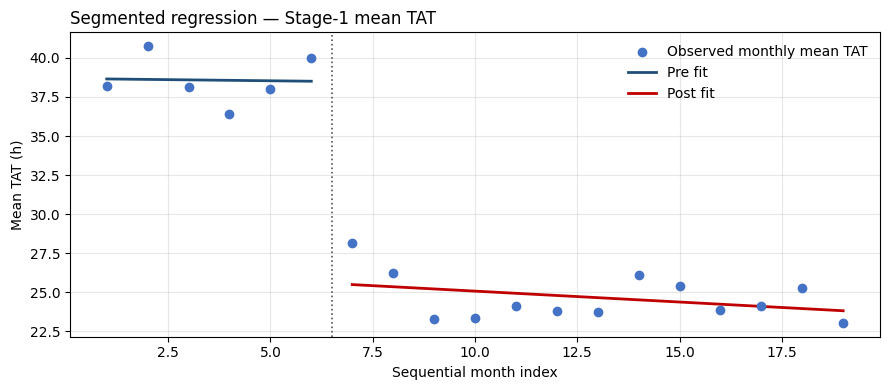

In [5]:
m = results['mean_processing_time']
df = s1.copy()
df['fitted'] = m.predict(sm.add_constant(
    pd.DataFrame({'t': df.month_index,
                  'D': (df.month_index>=T_STAR).astype(int),
                  't_post': (df.month_index-T_STAR).clip(lower=0)
                            * (df.month_index>=T_STAR).astype(int)})))
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df.month_index, df.mean_processing_time, color='#4472C4',
    label='Observed monthly mean TAT', zorder=3)
ax.plot(df[df.era==0].month_index, df[df.era==0].fitted, '-',
    color='#1F4E79', lw=2, label='Pre fit')
ax.plot(df[df.era==1].month_index, df[df.era==1].fitted, '-',
    color='#C00000', lw=2, label='Post fit')
ax.axvline(T_STAR-0.5, color='#555', ls=':', lw=1.2)
ax.set_xlabel('Sequential month index'); ax.set_ylabel('Mean TAT (h)')
ax.set_title('Segmented regression — Stage-1 mean TAT', loc='left')
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()